# 04 — 채널 임베딩 K-means 클러스터링

03번 파이프라인에서 만든 **`channel_embeddings.npy`**와 **`channel_metadata.csv`**를 읽어, 고차원 임베딩에 대해 **K-means**를 수행합니다.

- **k 선택:** `K_MIN`~`K_MAX` 범위에서 각 k에 대해 클러스터링 후 **실루엣 계수(silhouette, metric=euclidean)**를 계산하고, **최대 실루엣**에 해당하는 k를 채택합니다.
- **저장 파일 (모델별 `artifacts/{카테고리}/embeddings/{모델}/` 아래):**
  - `kmeans_labels_k{k}.csv` — `channel_id`, `channel_name`, `n_videos`, `cluster_id`
  - `kmeans_sweep.json` — k별 실루엣 등 스윕 결과
  - `kmeans_summary.json` — 선정 k·요약 메타데이터
- **선택 시각화:** `SAVE_UMAP_COLORED=True`이면 UMAP 2D 산점도를 **클러스터 색상**으로 칠해 `artifacts/{카테고리}/visualizations/{모델}/umap_kmeans_k{k}.png`에 저장합니다 (`n_neighbors`는 03과 같이 샘플 수에 맞게 상한 처리).

In [1]:
from __future__ import annotations

import csv
import json
import os
from pathlib import Path
from typing import List, Tuple

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
# Windows + MKL: KMeans 메모리 누수 경고 완화 (sklearn 권장)
os.environ.setdefault("OMP_NUM_THREADS", "4")

_marker = Path("YT_dataset_health.csv")
if not _marker.exists():
    for p in Path.cwd().rglob("YT_dataset_health.csv"):
        os.chdir(p.parent)
        break
print(f"CWD: {Path.cwd()}")

DATASETS: List[Tuple[str, Path]] = [
    ("health", Path("YT_dataset_health.csv")),
    ("food", Path("YT_dataset_food.csv")),
    ("VLOG", Path("YT_dataset_VLOG.csv")),
    ("society", Path("YT_dataset_society.csv")),
    ("education", Path("YT_dataset_education.csv")),
]

ARTIFACTS_BASE = Path("artifacts")
MODEL_DIRS = ["dinov2-base", "siglip2-base"]

RANDOM_STATE = 42
K_MIN = 2
K_MAX = 12
SAVE_UMAP_COLORED = True
UMAP_NEIGHBORS = 20
UMAP_MIN_DIST = 0.1
UMAP_RANDOM_STATE = 42

print("설정 완료")
print(f"  카테고리: {[c for c, _ in DATASETS]}")
print(f"  모델 디렉터리: {MODEL_DIRS}")
print(f"  k 범위: {K_MIN}..{K_MAX} (실루엣 최대)")
print(f"  산출: {ARTIFACTS_BASE}/{{카테고리}}/embeddings/{{모델}}/")


CWD: g:\내 드라이브\0. 포트폴리오\프로젝트\[260302-260631] 26-1 URP
설정 완료
  카테고리: ['health', 'food', 'VLOG', 'society', 'education']
  모델 디렉터리: ['dinov2-base', 'siglip2-base']
  k 범위: 2..12 (실루엣 최대)
  산출: artifacts/{카테고리}/embeddings/{모델}/


In [2]:
from typing import Any, Dict, List as ListType, Optional, Tuple as TupleType

import numpy as np


def ensure_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)


def read_csv_rows(path: Path, encoding: str = "utf-8-sig") -> ListType[Dict[str, str]]:
    with path.open("r", encoding=encoding, newline="") as f:
        return list(csv.DictReader(f))


def pick_k_and_cluster(
    X: np.ndarray,
    k_min: int,
    k_max: int,
    random_state: int,
) -> TupleType[int, np.ndarray, ListType[Dict[str, Any]]]:
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score

    n = int(X.shape[0])
    k_lo = max(2, int(k_min))
    k_hi = min(int(k_max), n - 1)
    sweep: ListType[Dict[str, Any]] = []
    if k_lo > k_hi:
        raise ValueError(f"채널 수 n={n}에 대해 유효한 k가 없습니다 (필요: n>=3, k in [2, n-1]).")

    best_k: Optional[int] = None
    best_score = -1.0
    best_labels: Optional[np.ndarray] = None

    for k in range(k_lo, k_hi + 1):
        km = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
        labels = km.fit_predict(X)
        score = float(silhouette_score(X, labels, metric="euclidean"))
        sweep.append({"k": k, "silhouette": score})
        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels.astype(np.int64).copy()

    assert best_k is not None and best_labels is not None
    return best_k, best_labels, sweep


def run_one_model_dir(category: str, model_name: str) -> None:
    emb_dir = ARTIFACTS_BASE / category / "embeddings" / model_name
    npy_path = emb_dir / "channel_embeddings.npy"
    meta_path = emb_dir / "channel_metadata.csv"
    if not npy_path.exists() or not meta_path.exists():
        print(f"[{category}/{model_name}] 건너뜀 — {npy_path.name} 또는 {meta_path.name} 없음")
        return

    X = np.load(npy_path)
    rows = read_csv_rows(meta_path)
    assert X.shape[0] == len(rows), (
        f"행 수 불일치: embeddings {X.shape[0]} vs metadata {len(rows)} ({category}/{model_name})"
    )

    best_k, labels, sweep = pick_k_and_cluster(X, K_MIN, K_MAX, RANDOM_STATE)

    sweep_path = emb_dir / "kmeans_sweep.json"
    with sweep_path.open("w", encoding="utf-8") as f:
        json.dump({"category": category, "model": model_name, "sweep": sweep}, f, ensure_ascii=False, indent=2)
    print(f"  저장: {sweep_path}")

    label_rows: ListType[Dict[str, str]] = []
    for i, row in enumerate(rows):
        label_rows.append(
            {
                "channel_id": (row.get("channel_id") or "").strip(),
                "channel_name": (row.get("channel_name") or "").strip(),
                "n_videos": (row.get("n_videos") or "").strip(),
                "cluster_id": str(int(labels[i])),
            }
        )
    labels_csv = emb_dir / f"kmeans_labels_k{best_k}.csv"
    fields = ["channel_id", "channel_name", "n_videos", "cluster_id"]
    with labels_csv.open("w", encoding="utf-8", newline="") as f:
        w = csv.DictWriter(f, fieldnames=fields)
        w.writeheader()
        w.writerows(label_rows)
    print(f"  저장: {labels_csv}")

    best_sil = next(s["silhouette"] for s in sweep if s["k"] == best_k)
    summary = {
        "category": category,
        "model": model_name,
        "n_channels": int(X.shape[0]),
        "embedding_dim": int(X.shape[1]),
        "k_min": K_MIN,
        "k_max": K_MAX,
        "best_k": int(best_k),
        "best_silhouette_euclidean": float(best_sil),
        "labels_csv": str(labels_csv.as_posix()),
        "sweep_json": str(sweep_path.as_posix()),
        "random_state": RANDOM_STATE,
    }
    summary_path = emb_dir / "kmeans_summary.json"
    with summary_path.open("w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)
    print(f"  저장: {summary_path}")

    if SAVE_UMAP_COLORED:
        import matplotlib.pyplot as plt
        import umap as umap_lib

        n = int(X.shape[0])
        nn = min(UMAP_NEIGHBORS, max(2, n - 1))
        reducer = umap_lib.UMAP(
            n_components=2,
            n_neighbors=nn,
            min_dist=UMAP_MIN_DIST,
            metric="cosine",
            random_state=UMAP_RANDOM_STATE,
        )
        coords = reducer.fit_transform(X)
        viz_dir = ARTIFACTS_BASE / category / "visualizations" / model_name
        ensure_dir(viz_dir)
        out_png = viz_dir / f"umap_kmeans_k{best_k}.png"
        fig, ax = plt.subplots(figsize=(9, 7))
        sc = ax.scatter(
            coords[:, 0],
            coords[:, 1],
            c=labels,
            cmap="tab20",
            s=28,
            alpha=0.75,
            linewidths=0,
        )
        ax.set_title(
            f"UMAP (K-means k={best_k}) — {category} / {model_name} (n={n})",
            fontsize=13,
        )
        ax.set_xlabel("dim-1")
        ax.set_ylabel("dim-2")
        plt.colorbar(sc, ax=ax, label="cluster_id")
        fig.tight_layout()
        fig.savefig(out_png, dpi=180)
        plt.close(fig)
        print(f"  저장: {out_png}")


print("함수 정의 완료: read_csv_rows, pick_k_and_cluster, run_one_model_dir")


함수 정의 완료: read_csv_rows, pick_k_and_cluster, run_one_model_dir


In [3]:
for category, _csv in DATASETS:
    for model_name in MODEL_DIRS:
        print(f"\n=== {category} / {model_name} ===")
        run_one_model_dir(category, model_name)

print("\n전체 완료.")



=== health / dinov2-base ===
  저장: artifacts\health\embeddings\dinov2-base\kmeans_sweep.json
  저장: artifacts\health\embeddings\dinov2-base\kmeans_labels_k2.csv
  저장: artifacts\health\embeddings\dinov2-base\kmeans_summary.json


c:\Users\user\anaconda3\envs\ytvenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  저장: artifacts\health\visualizations\dinov2-base\umap_kmeans_k2.png

=== health / siglip2-base ===
  저장: artifacts\health\embeddings\siglip2-base\kmeans_sweep.json
  저장: artifacts\health\embeddings\siglip2-base\kmeans_labels_k2.csv
  저장: artifacts\health\embeddings\siglip2-base\kmeans_summary.json


c:\Users\user\anaconda3\envs\ytvenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  저장: artifacts\health\visualizations\siglip2-base\umap_kmeans_k2.png

=== food / dinov2-base ===
  저장: artifacts\food\embeddings\dinov2-base\kmeans_sweep.json
  저장: artifacts\food\embeddings\dinov2-base\kmeans_labels_k2.csv
  저장: artifacts\food\embeddings\dinov2-base\kmeans_summary.json


...

  저장: artifacts\society\visualizations\siglip2-base\umap_kmeans_k2.png

=== education / dinov2-base ===
  저장: artifacts\education\embeddings\dinov2-base\kmeans_sweep.json
  저장: artifacts\education\embeddings\dinov2-base\kmeans_labels_k2.csv
  저장: artifacts\education\embeddings\dinov2-base\kmeans_summary.json


c:\Users\user\anaconda3\envs\ytvenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  저장: artifacts\education\visualizations\dinov2-base\umap_kmeans_k2.png

=== education / siglip2-base ===
  저장: artifacts\education\embeddings\siglip2-base\kmeans_sweep.json
  저장: artifacts\education\embeddings\siglip2-base\kmeans_labels_k2.csv
  저장: artifacts\education\embeddings\siglip2-base\kmeans_summary.json


c:\Users\user\anaconda3\envs\ytvenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  저장: artifacts\education\visualizations\siglip2-base\umap_kmeans_k2.png

전체 완료.


---
## 결과 시각화 (UMAP + K-means 색상)

`artifacts/{카테고리}/visualizations/{모델}/umap_kmeans_k*.png` 파일을 찾아 한 번에 표시합니다. (클러스터 실행 셀을 먼저 돌린 뒤 실행하세요.)

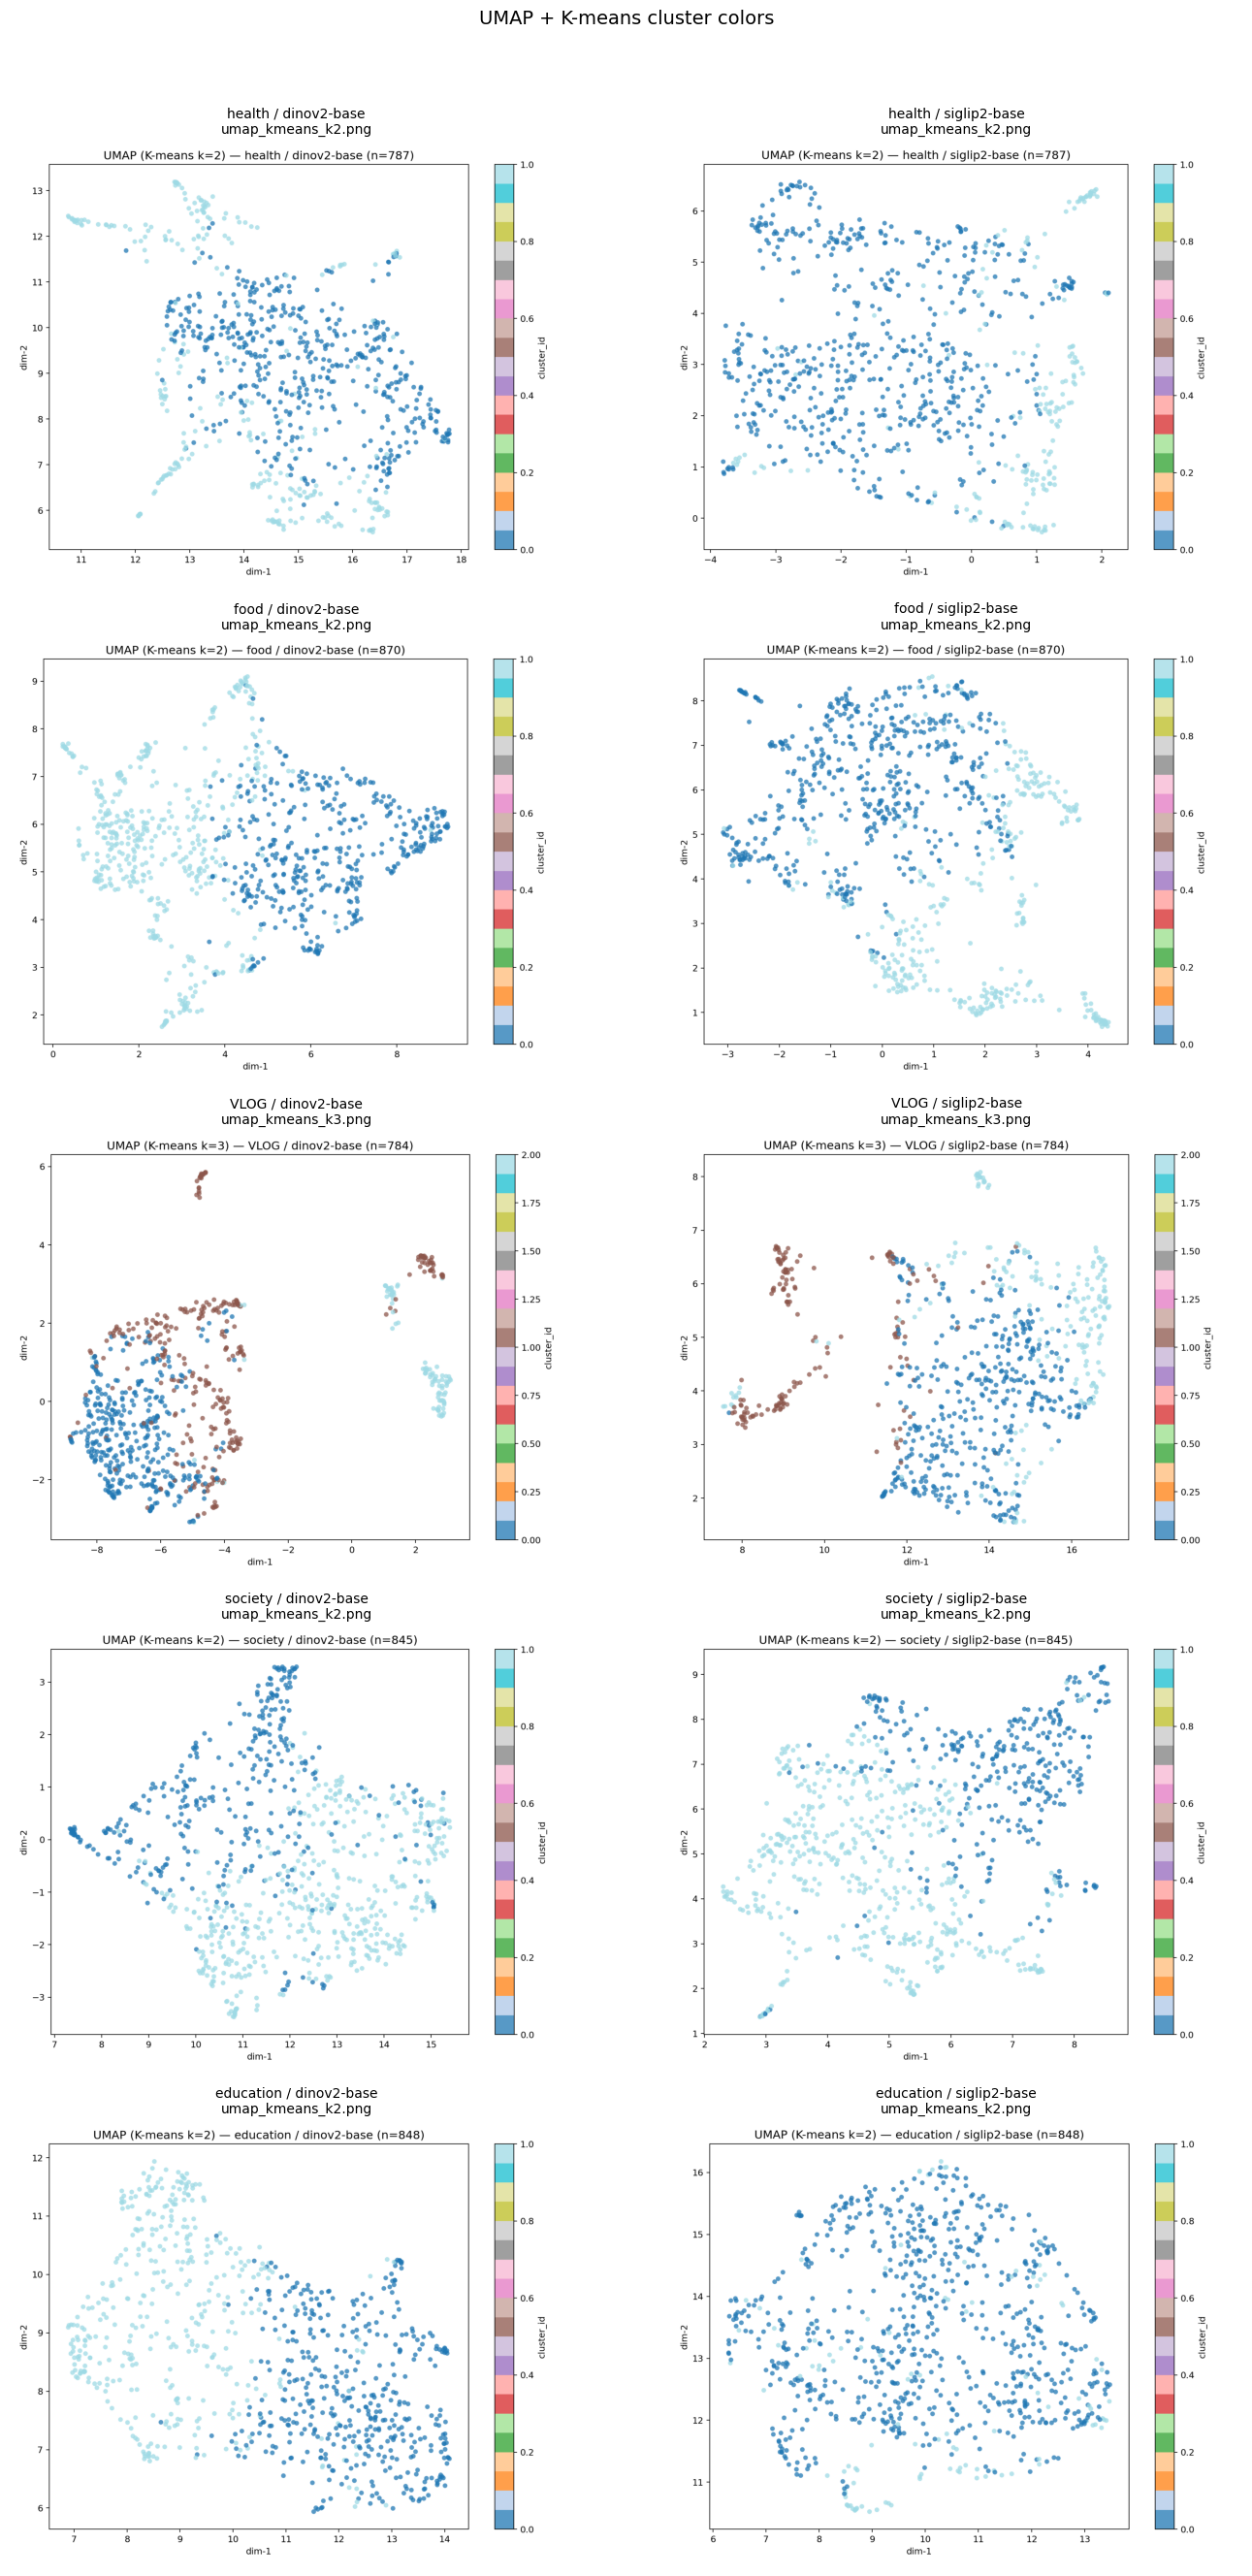

총 10장 표시


In [4]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt


def show_kmeans_umap_results(cols: int = 2) -> None:
    paths: list[Path] = []
    for cat, _ in DATASETS:
        for m in MODEL_DIRS:
            vdir = ARTIFACTS_BASE / cat / "visualizations" / m
            if not vdir.is_dir():
                continue
            paths.extend(sorted(vdir.glob("umap_kmeans_k*.png")))

    if not paths:
        print("표시할 umap_kmeans_k*.png 가 없습니다. SAVE_UMAP_COLORED=True 로 위 실행 셀을 먼저 실행하세요.")
        return

    n = len(paths)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 7.2, rows * 5.2))
    flat = list(axes.flat) if hasattr(axes, "flat") else [axes]

    for ax, p in zip(flat, paths):
        ax.imshow(mpimg.imread(p))
        try:
            rel = p.relative_to(ARTIFACTS_BASE)
            cat, _, model, fname = rel.parts[0], rel.parts[1], rel.parts[2], rel.parts[3]
            title = f"{cat} / {model}\n{fname}"
        except Exception:
            title = str(p)
        ax.set_title(title, fontsize=10)
        ax.axis("off")

    for ax in flat[n:]:
        ax.axis("off")

    fig.suptitle("UMAP + K-means cluster colors", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    print(f"총 {n}장 표시")


show_kmeans_umap_results(cols=2)